# Denoising Autoencoder on MNIST

# 1. Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import os, gzip, struct, glob
import torch.nn as nn

# 2. Seeding
* Seeding for constant results

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

**Seeding**
* without a fixed seed every when the file is executed it would give slightly different results that's why fixing it makes it easier to get game results.

# 3. Downloading MNIST dataset

In [3]:
# >> Downloading MNIST dataset from torchvision (train/test both)
train = datasets.MNIST(root="./data", train=True,  download=True)
test  = datasets.MNIST(root="./data", train=False, download=True)

x_train = train.data.float().unsqueeze(1) / 255.0
x_test = test.data.float().unsqueeze(1) / 255.0
y_train = train.targets
y_test = test.targets

print("train images:", tuple(x_train.shape))
print("test images:", tuple(x_test.shape))
print("pixel range:", float(x_train.min()), "to", float(x_train.max()))

train images: (60000, 1, 28, 28)
test images: (10000, 1, 28, 28)
pixel range: 0.0 to 1.0


**Downloaded MNIST using torchvision**

* The pixels were integers 0–255 I've scale them to the [0, 1] range by dividing with 255. Because later i'll use "Sigmoid" decoder whose output is bounded to [0, 1].

# 4. Sanity check before Traning

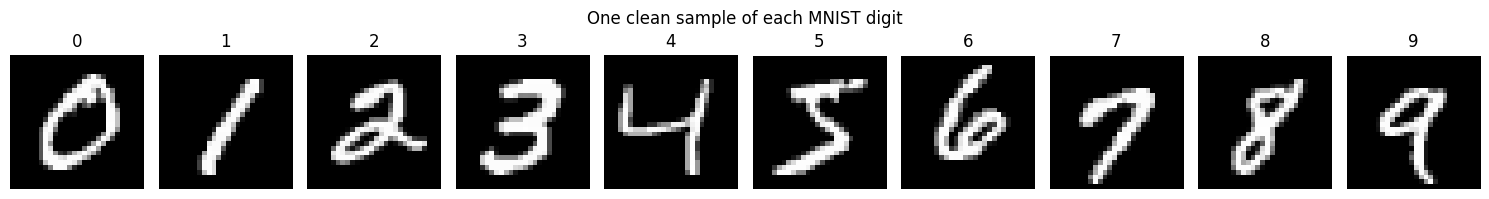

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for digit in range(10):
    idx = (y_train == digit).nonzero()[0][0]
    axes[digit].imshow(x_train[idx, 0], cmap="gray")
    axes[digit].set_title(str(digit))
    axes[digit].axis("off")
plt.suptitle("One clean sample of each MNIST digit")
plt.tight_layout()
plt.show()

# 5. Noise Factoring

In [5]:
NOISE_FACTOR = 0.5

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)

torch.manual_seed(SEED)
x_test_noisy = add_noise(x_test)
print("noisy test pixel range:", float(x_test_noisy.min()), "to", float(x_test_noisy.max()))

noisy test pixel range: 0.0 to 1.0


**Ideology:**
- **torch.clamp():** Adding noise causes the pixels to go below 0 or above 1 which is incossistent as per the pixal if image it should be between 0 and 1. Clipping keeps the noisy image in the same range between 0 and 1.
- **fixed noise:** I've freeze the test set with a seed so that when I compare "noisy vs clean" against "denoised vs clean" easliy.

# 6. Comparining Clean and Noisy data

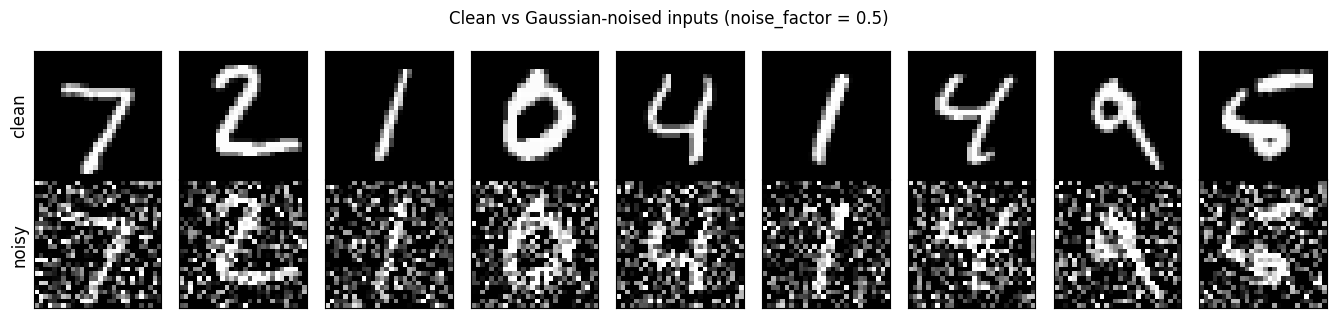

In [6]:
n = 9
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3.2))
for i in range(n):
    for r, (label, data) in enumerate([("clean", x_test), ("noisy", x_test_noisy)]):
        ax = axes[r, i]
        ax.imshow(data[i, 0], cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_ylabel(label, fontsize=12)
plt.suptitle(f"Clean vs Gaussian-noised inputs (noise_factor = {NOISE_FACTOR})")
plt.tight_layout(); plt.show()

**Observation**
* This is the problem model has to solve. The bottom row is actual degraded there's a heavy speckle and noise and some digits are blured into the background.

# 7. Data Loading and Noising

In [7]:
BATCH_SIZE = 128

clean_train = TensorDataset(x_train)
clean_val = TensorDataset(x_test)

train_loader = DataLoader(clean_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(clean_val, batch_size=BATCH_SIZE, shuffle=False)

**Ideology:**
* The dataset contains (noisy, clean) this is supervised dataset. The model is told "here's the messy version and here's the expected version".

* Batch size of 128 is comfortable enough for stable gradients.

# 8. Model Structure

In [8]:
device = torch.device("cuda")

model = nn.Sequential(
    # Encoder
    nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
    nn.ReLU(inplace=True),

    # Decoder
    nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
    nn.Sigmoid()).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(model)

Trainable parameters: 37,569
Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (5): ReLU(inplace=True)
  (6): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (7): Sigmoid()
)


**Insights**
* **Sigmoid** bounds outputs to [0, 1]

* **Optimiser(Adam at lr=1e-3)** Adam adapts the learning rate. 1e-3 is the well known same default.
* **Loss — Mean Squared Error.** Denoising is a regression problem each output pixel should match the corresponding clean pixel.

# 9. Model Traning

In [9]:
EPOCHS = 10
def run_epoch(loader, train=True):
    model.train() if train else model.eval()

    running = 0.0
    grad_context = torch.enable_grad() if train else torch.no_grad()

    with grad_context:
        for (clean,) in loader:
            clean = clean.to(device)
            noisy = add_noise(clean, NOISE_FACTOR)

            output = model(noisy)
            loss = criterion(output, clean)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running += loss.item() * clean.size(0)

    return running / len(loader.dataset)


train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)

    train_losses.append(tr)
    val_losses.append(va)

    print(f"Epoch {epoch:2d}/{EPOCHS} train MSE: {tr:.5f} val MSE: {va:.5f}")

Epoch  1/10 train MSE: 0.02952 val MSE: 0.01406
Epoch  2/10 train MSE: 0.01376 val MSE: 0.01322
Epoch  3/10 train MSE: 0.01316 val MSE: 0.01281
Epoch  4/10 train MSE: 0.01280 val MSE: 0.01252
Epoch  5/10 train MSE: 0.01256 val MSE: 0.01229
Epoch  6/10 train MSE: 0.01235 val MSE: 0.01211
Epoch  7/10 train MSE: 0.01221 val MSE: 0.01199
Epoch  8/10 train MSE: 0.01207 val MSE: 0.01196
Epoch  9/10 train MSE: 0.01200 val MSE: 0.01180
Epoch 10/10 train MSE: 0.01186 val MSE: 0.01171


**Ideology**
* I've used the PyTorch model trained in a loop and reused that for validation too. These are the the learning steps zero_grad -> forward -> backward -> step.

# 10. Ploting Traning and validation loss

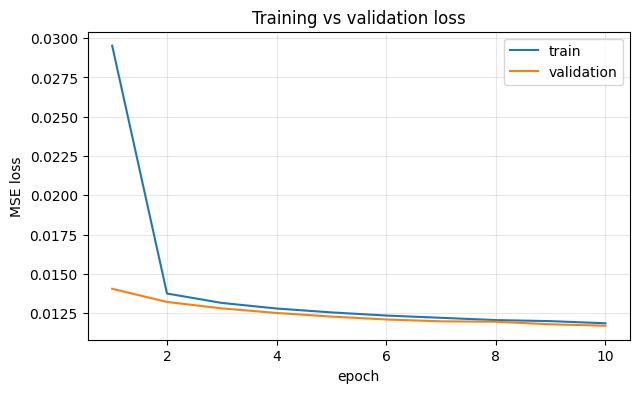

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label="train")
plt.plot(range(1, EPOCHS + 1), val_losses, label="validation")
plt.xlabel("epoch"); plt.ylabel("MSE loss")
plt.title("Training vs validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Observation:**
* **train and validation:** MSE both fall quickly in the first few epochs and then flatten out. Because the validation noise is frozen this states that model was improving and has actually learned data.

# 11. Plotting Actual, Noisy and Output(Denoised) data

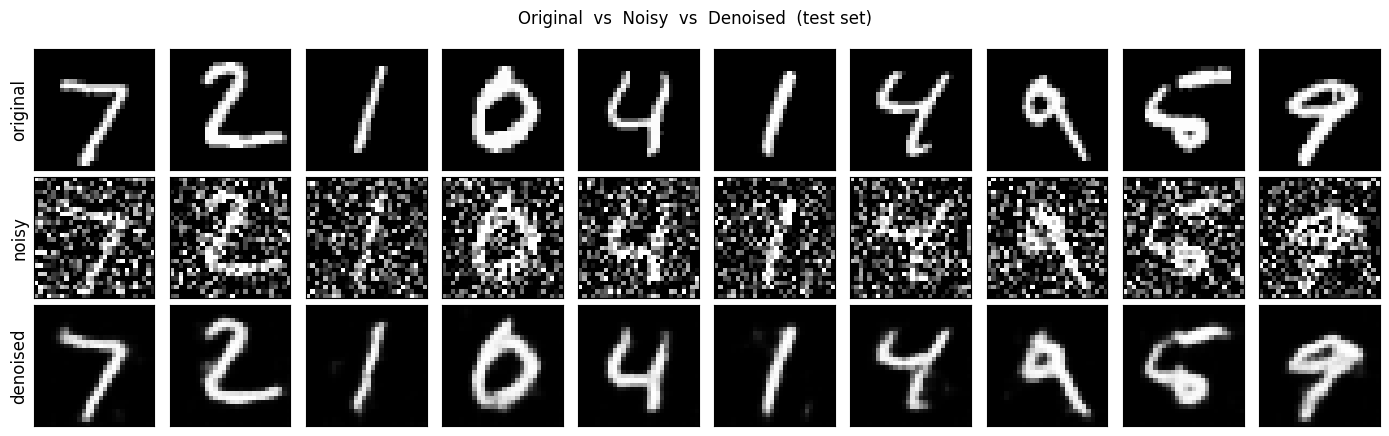

In [11]:
model.eval()
with torch.no_grad():
    denoised = model(x_test_noisy.to(device)).cpu()

n = 10
fig, axes = plt.subplots(3, n, figsize=(n * 1.4, 4.4))
rows = [("original", x_test), ("noisy", x_test_noisy), ("denoised", denoised)]
for i in range(n):
    for r, (label, data) in enumerate(rows):
        ax = axes[r, i]
        ax.imshow(data[i, 0], cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_ylabel(label, fontsize=12)
plt.suptitle("Original  vs  Noisy  vs  Denoised  (test set)")
plt.tight_layout(); plt.show()

**Observation:**
* The **First Row original** is the actual data
* The **Middle Row noisy** is the heavily speckled input the model actually received to train on
* The **Last Row denoised** bottom row is what the network produces(Output).

> the speckle is entirely gone and the digit shapes are clearly seen and are easy to read. But there is a slight **softness/blur** in the output. That blur/softness is because model tries to remove the noise completly and that make some image pixel to be removed from edges too by the model.

# 12. PSNR and SSIM's Matrics

In [12]:
def mean_psnr_ssim(clean, recon):
    clean = clean.squeeze(1).numpy()
    recon = recon.squeeze(1).numpy()
    ps = [psnr_metric(c, r, data_range=1.0) for c, r in zip(clean, recon)]
    ss = [ssim_metric(c, r, data_range=1.0) for c, r in zip(clean, recon)]
    return float(np.mean(ps)), float(np.mean(ss))

base_psnr, base_ssim = mean_psnr_ssim(x_test, x_test_noisy)
den_psnr,  den_ssim  = mean_psnr_ssim(x_test, denoised)

print(f"Noisy    -> PSNR: {base_psnr:5.2f} dB SSIM: {base_ssim:.3f}")
print(f"Denoised -> PSNR: {den_psnr:5.2f} dB SSIM: {den_ssim:.3f}")
print(f"Improvement: +{den_psnr - base_psnr:.2f} dB PSNR, +{den_ssim - base_ssim:.3f} SSIM")

Noisy    -> PSNR:  9.38 dB SSIM: 0.375
Denoised -> PSNR: 19.61 dB SSIM: 0.837
Improvement: +10.22 dB PSNR, +0.462 SSIM


**Ideology:**
> I've measured two metrics:
- **PSNR** (peak signal-to-noise ratio, in dB) — higher is better;
- **SSIM** (structural similarity, 0–1) — higher is better; it's closer to *human* perception because it rewards matching structure and contrast rather than exact pixel values.

SSIM is more reliable for such task. Because of the slight MSE blur noted above and it is meaningfully as it matches the human eye test.

# 13. Experimenting different Noises
* Ploted there Graphs too

noise_factor=0.2 -> denoised PSNR 23.83 dB | SSIM 0.940
noise_factor=0.4 -> denoised PSNR 21.18 dB | SSIM 0.895
noise_factor=0.6 -> denoised PSNR 17.86 dB | SSIM 0.740
noise_factor=0.8 -> denoised PSNR 14.59 dB | SSIM 0.548
noise_factor=1.0 -> denoised PSNR 12.40 dB | SSIM 0.427


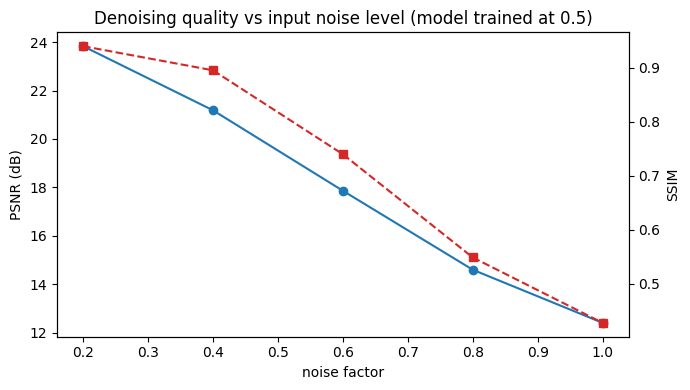

In [13]:
levels = [0.2, 0.4, 0.6, 0.8, 1.0]
sweep_psnr, sweep_ssim = [], []
model.eval()
for nf in levels:
    torch.manual_seed(SEED)
    noisy = add_noise(x_test, noise_factor=nf)
    with torch.no_grad():
        rec = model(noisy.to(device)).cpu()
    p, s = mean_psnr_ssim(x_test, rec)
    sweep_psnr.append(p); sweep_ssim.append(s)
    print(f"noise_factor={nf:.1f} -> denoised PSNR {p:5.2f} dB | SSIM {s:.3f}")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(levels, sweep_psnr, "o-", color="tab:blue", label="PSNR")
ax1.set_xlabel("noise factor"); ax1.set_ylabel("PSNR (dB)")
ax2 = ax1.twinx()
ax2.plot(levels, sweep_ssim, "s--", color="tab:red", label="SSIM")
ax2.set_ylabel("SSIM")
plt.title("Denoising quality vs input noise level (model trained at 0.5)")
fig.tight_layout(); plt.show()

**Experiment**
* In this i've experimented with different noise_factors.

*Findings:* quality degrades as the noise rises — both PSNR and SSIM slope moves downwards near to 0.8–1.0 it goes too low where the digit are itself starts to vanish too much noice is there. On the easier lower-noise the model does well good PSNR ans SSIM is there.

# 14. Saving Model

In [14]:
torch.save(model.state_dict(), "denoising_autoencoder_mnist.pth")

# Conclusion

 The conv model is trained on (clear and noise) image pair. The encoder compresses and passes to bottleneck and it pass to the decoder it rebuilds the image and then sigmoid layer give that image in to 0 to 1 range which is image pixals **(Encoder -> Bottleneck -> Decoder -> Sigmoid)**. I've used MSE loss and the Adam optimiser.

**Few Important data processing i've done**
- **Seeding:** It can be said as a small step but it gives the consitant result each time i execute a file.
- **Normalising to [0,1]** i've normalised the data by dividing with 255 as this was the max number which make the data range between 0 to 1.
- **Clipping: ** when i performed noising it caused the values to go beyond and below 0 and 1 i've clipped them.

**Observations**
- **Slight blurry/soften reconstructions** That because model tries to minimize the loss by removing the nosie as much as possbile but the problem is when it tries to do so it removes some pixals from edges which cases digites to get softer and blury.
- **Noise level Impact** Higher the noice harder it will for model to perduce better result. As when the noise increase the image get more noisy and blur make it harder for model to produce and understand and it cause wrong or blury unclear output.

# Finally
At the end at 0.5 noise factor the model image output was top of the line i can easily identify the images and the Actual and the output image is too close it each other.
> These were the matrices:
* Noisy -> PSNR:  9.38 dB SSIM: 0.375
* Denoised -> PSNR: 19.62 dB SSIM: 0.838
* Improvement: +10.24 dB PSNR, +0.462 SSIM